# Proyecto 1 — Riesgo Crediticio en Fintech
### Fase 1: EDA inicial y Auditoría de Calidad de Datos

**Caso:** Caso 2 — Organización privada (Finanzas / Banca-Fintech)
**Dataset:** `deudores_tarjeta_credito.csv` — 55.000 clientes con historial de tarjeta de crédito
**Objetivo de esta notebook:** cargar el dataset, entender su estructura, y auditar su calidad
siguiendo las 6 dimensiones de calidad de datos, antes de avanzar a cualquier modelado.

> Esta notebook cubre **Fase 1 (Análisis de Datos)** del checkpoint: EDA, calidad de datos,
> detección de sesgos y clasificación de datos faltantes (MCAR/MAR/MNAR).


## 1. Setup e importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


## 2. Carga de datos

Cargamos el CSV y hacemos una primera inspección: dimensiones, tipos de datos y una muestra
de las primeras filas. Esto es el punto de partida antes de cualquier limpieza.

In [2]:
df = pd.read_csv('deudores_tarjeta_credito.csv')

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
df.head()


Filas: 55,000
Columnas: 19


,id_cliente,edad,genero,estado_civil,nivel_educativo,situacion_laboral,antiguedad_laboral_meses,ingreso_mensual,limite_credito,saldo_actual,ratio_uso_credito,num_dependientes,num_prestamos_activos,atrasos_ultimos_12m,score_crediticio_previo,deuda_total,ratio_deuda_ingreso,antiguedad_cliente_meses,default_flag
0,100001,46,F,Soltero/a,Universitario,Desempleado,1.0,793857.0,1447430.0,628964.0,435.00,0.0,2,2.0,472.0,733691.0,77.00,27,0
1,100002,38,M,Soltero/a,Universitario,Relacion de dependencia,139.0,625123.0,1712616.0,369782.0,216.00,2.0,2,0.0,706.0,603674.0,0.08,18,0
2,100003,48,F,Soltero/a,Secundario,Jubilado,80.0,235620.0,898166.0,472834.0,526.00,2.0,2,0.0,651.0,798947.0,283.00,71,0
3,100004,58,M,Casado/a,Universitario,Independiente/Monotributista,4.0,1607930.0,4423856.0,796083.0,0.18,3.0,3,0.0,701.0,1833400.0,95.00,42,0
4,100005,37,F,Soltero/a,Posgrado,Relacion de dependencia,22.0,334135.0,1228880.0,822223.0,669.00,NaN,2,0.0,NaN,1404126.0,0.35,29,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_cliente                55000 non-null  int64  
 1   edad                      55000 non-null  int64  
 2   genero                    55000 non-null  object 
 3   estado_civil              55000 non-null  object 
 4   nivel_educativo           55000 non-null  object 
 5   situacion_laboral         55000 non-null  object 
 6   antiguedad_laboral_meses  50220 non-null  float64
 7   ingreso_mensual           47868 non-null  float64
 8   limite_credito            55000 non-null  float64
 9   saldo_actual              55000 non-null  float64
 10  ratio_uso_credito         55000 non-null  float64
 11  num_dependientes          51826 non-null  float64
 12  num_prestamos_activos     55000 non-null  int64  
 13  atrasos_ultimos_12m       52325 non-null  float64
 14  score_

**Diccionario de variables (según los nombres de columna):**

| Variable | Descripción |
|---|---|
| `id_cliente` | Identificador único del cliente |
| `edad` | Edad del cliente |
| `genero` | F / M |
| `estado_civil` | Soltero/a, Casado/a, Divorciado/a, Viudo/a |
| `nivel_educativo` | Secundario, Terciario, Universitario, Posgrado |
| `situacion_laboral` | Relación de dependencia, Independiente/Monotributista, Desempleado, Jubilado |
| `antiguedad_laboral_meses` | Meses en el empleo actual |
| `ingreso_mensual` | Ingreso mensual declarado |
| `limite_credito` | Límite de la tarjeta de crédito |
| `saldo_actual` | Saldo adeudado actual |
| `ratio_uso_credito` | Saldo actual / límite de crédito |
| `num_dependientes` | Cantidad de personas a cargo |
| `num_prestamos_activos` | Cantidad de préstamos activos |
| `atrasos_ultimos_12m` | Cantidad de atrasos de pago en los últimos 12 meses |
| `score_crediticio_previo` | Score crediticio otorgado por un buró previo |
| `deuda_total` | Deuda total del cliente (todas las fuentes) |
| `ratio_deuda_ingreso` | Deuda total / ingreso mensual |
| `antiguedad_cliente_meses` | Meses de antigüedad como cliente del banco |
| `default_flag` | Variable objetivo: 1 = entró en default, 0 = no |


## 3. Auditoría de calidad de datos — las 6 dimensiones

Recorremos las seis dimensiones clásicas de calidad de datos: **completitud, unicidad,
consistencia, validez, exactitud y actualidad**. Para cada una buscamos evidencia concreta
en el dataset, no una afirmación genérica.

### 3.1 Completitud (¿faltan datos?)

In [4]:
nulos = df.isna().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
completitud = pd.DataFrame({'nulos': nulos, 'pct_nulos': pct_nulos})
completitud = completitud[completitud['nulos'] > 0].sort_values('pct_nulos', ascending=False)
completitud


,nulos,pct_nulos
ingreso_mensual,7132,12.97
score_crediticio_previo,6939,12.62
antiguedad_laboral_meses,4780,8.69
num_dependientes,3174,5.77
atrasos_ultimos_12m,2675,4.86


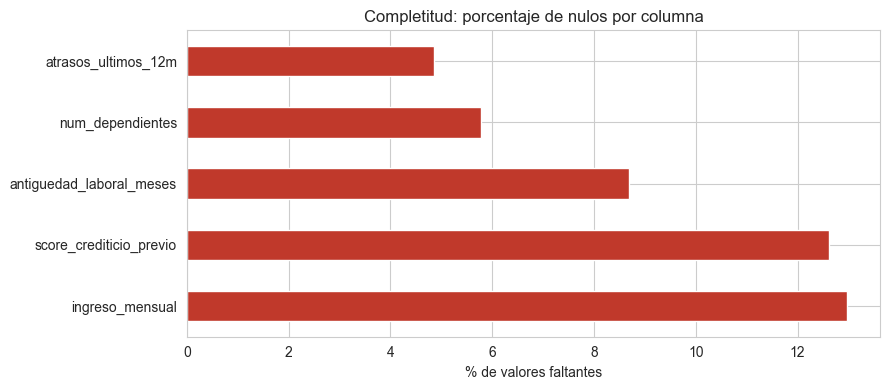

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
completitud['pct_nulos'].plot(kind='barh', ax=ax, color='#c0392b')
ax.set_xlabel('% de valores faltantes')
ax.set_title('Completitud: porcentaje de nulos por columna')
plt.tight_layout()
plt.show()


**Lectura:** cinco columnas tienen datos faltantes, con `score_crediticio_previo` como la
más afectada (~12-13%), seguida de `ingreso_mensual` (~13%), `antiguedad_laboral_meses` (~8-9%),
`num_dependientes` (~5-6%) y `atrasos_ultimos_12m` (~4-5%). Ninguna columna clave para el
target (`default_flag`, `deuda_total`, `saldo_actual`, `limite_credito`) tiene faltantes,
lo cual es una buena noticia para el modelado posterior — pero varias de las variables con
faltantes son justamente las que más importan para explicar el riesgo crediticio.

### Decisiones que se trasladan al ETL

A partir de esta auditoría dejamos definidas las transformaciones a realizar en `ETL_riesgo_crediticio.ipynb`:

- `ingreso_mensual` y `score_crediticio_previo`: faltantes clasificados como **MAR**; imputación por grupos y conservación de un indicador de imputación.
- `atrasos_ultimos_12m` y `num_dependientes`: hipótesis **MCAR**; imputación con la moda.
- `antiguedad_laboral_meses`: posible **MNAR**; tratamiento provisorio e indicador de faltante, pendiente de validar con negocio.
- `ratio_uso_credito`: normalización a una única escala antes de utilizarlo en análisis posteriores.


### 3.2 Unicidad (¿hay registros o identificadores duplicados?)

In [6]:
print("Filas duplicadas (todas las columnas):", df.duplicated().sum())
print("IDs de cliente duplicados:", df['id_cliente'].duplicated().sum())
print("¿id_cliente es único?:", df['id_cliente'].is_unique)


Filas duplicadas (todas las columnas): 0
IDs de cliente duplicados: 0
¿id_cliente es único?: True


**Lectura:** no hay filas duplicadas ni `id_cliente` repetidos — la unicidad no es un problema en este dataset.

### 3.3 Consistencia (¿los datos son coherentes entre sí y con las reglas de negocio?)

Un chequeo simple: `ratio_uso_credito` debería ser matemáticamente igual a
`saldo_actual / limite_credito`. Lo mismo con `ratio_deuda_ingreso` respecto a
`deuda_total / ingreso_mensual`. Si no coinciden, hay un problema de consistencia
en la forma en que se calculó o cargó la columna.

In [7]:
df['ratio_uso_calc'] = df['saldo_actual'] / df['limite_credito']

# ¿En qué escala está cargado ratio_uso_credito respecto al valor calculado?
df['factor_escala'] = df['ratio_uso_credito'] / df['ratio_uso_calc']

print(df['factor_escala'].describe())
print()
print("Filas donde el factor de escala ronda 1 (proporción 0-1):",
      ((df['factor_escala'] > 0.9) & (df['factor_escala'] < 1.1)).sum())
print("Filas donde el factor de escala ronda 1000 (por mil):",
      ((df['factor_escala'] > 900) & (df['factor_escala'] < 1100)).sum())


count    55000.000000
mean       900.523099
std        299.154357
min          0.952450
25%        999.112435
50%        999.867334
75%       1000.551184
max       1091.145248
Name: factor_escala, dtype: float64

Filas donde el factor de escala ronda 1 (proporción 0-1): 5477
Filas donde el factor de escala ronda 1000 (por mil): 49522


**Hallazgo de consistencia (importante):** `ratio_uso_credito` **no está cargado en una
escala uniforme**. Alrededor del 90% de las filas tienen el ratio expresado "por mil"
(ej. 435 en vez de 0.435), mientras que el ~10% restante está expresado como proporción
directa (ej. 0.18). Es el mismo campo, la misma unidad de negocio, pero con dos convenciones
de carga distintas mezcladas — probablemente por un error de integración entre dos fuentes o
sistemas de origen. Esto **hay que corregirlo antes de usar la variable** (llevar todo a la
misma escala 0-1), porque si no se distorsiona cualquier estadística o modelo que la use.

Vamos a confirmarlo visualmente y después chequear si `ratio_deuda_ingreso` tiene el mismo problema.

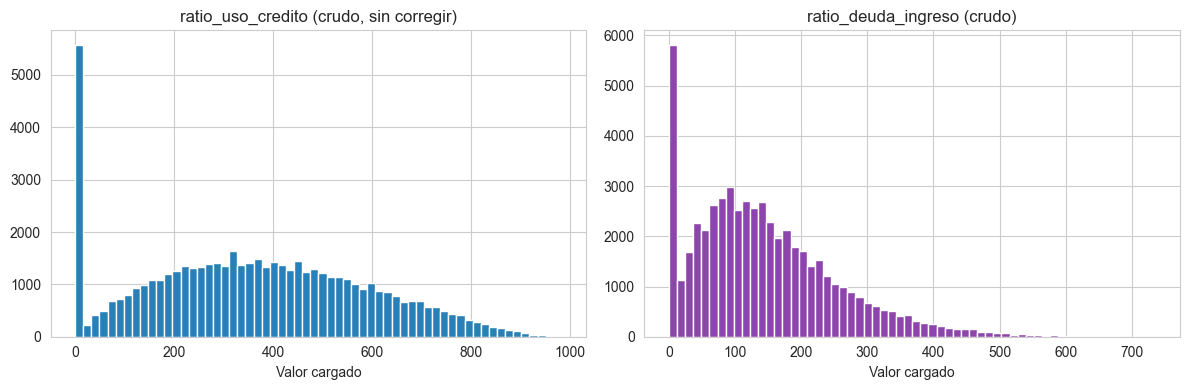

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['ratio_uso_credito'].hist(bins=60, ax=axes[0], color='#2980b9')
axes[0].set_title('ratio_uso_credito (crudo, sin corregir)')
axes[0].set_xlabel('Valor cargado')

df['ratio_deuda_ingreso'].hist(bins=60, ax=axes[1], color='#8e44ad')
axes[1].set_title('ratio_deuda_ingreso (crudo)')
axes[1].set_xlabel('Valor cargado')
plt.tight_layout()
plt.show()


In [9]:
df['ratio_deuda_calc'] = df['deuda_total'] / df['ingreso_mensual']
sub = df.dropna(subset=['ingreso_mensual'])
factor2 = sub['ratio_deuda_ingreso'] / sub['ratio_deuda_calc']
print(factor2.describe())


count    47868.000000
mean        75.161825
std         24.773815
min          0.079691
25%         83.129852
50%         83.304492
75%         83.452044
max        103.601983
dtype: float64


**Lectura:** en cambio, `ratio_deuda_ingreso` **no reconstruye de forma limpia** a partir de
`deuda_total / ingreso_mensual` (el factor de escala varía mucho, sin agruparse en 1 o en 1000).
Esto sugiere que el ratio fue calculado con otra base de ingreso (por ejemplo, ingreso anual,
ingreso del hogar, o un ingreso histórico distinto al que quedó registrado en `ingreso_mensual`),
o que directamente son dos fuentes de datos independientes que no se reconciliaron. Es un punto
para preguntarle al área de negocio: **¿quién genera cada uno de estos dos campos, y con qué
definición?** — no alcanza con inferirlo solo con los datos.

### Decisión para el ETL

Para corregir la inconsistencia de `ratio_uso_credito`, en el ETL se recalcula una nueva variable a partir de su definición:

`ratio_uso_credito_normalizado = saldo_actual / limite_credito`

Se conserva la columna original para mantener trazabilidad.


### 3.4 Validez (¿los valores respetan el dominio esperado?)

In [10]:
print("Rango de edad:", df['edad'].min(), '-', df['edad'].max())
print("Rango de score_crediticio_previo:", df['score_crediticio_previo'].min(), '-', df['score_crediticio_previo'].max())
print("Valores negativos en columnas numéricas:")
num_cols = df.select_dtypes(include=[np.number]).columns
for c in num_cols:
    n_neg = (df[c] < 0).sum()
    if n_neg > 0:
        print(f"  {c}: {n_neg} valores negativos")
print("(si no se imprimió nada arriba, no hay negativos)")
print()
print("Categorías de cada variable categórica:")
for c in ['genero', 'estado_civil', 'nivel_educativo', 'situacion_laboral']:
    print(f"  {c}: {sorted(df[c].unique())}")
print()
print("default_flag, valores únicos:", df['default_flag'].unique())


Rango de edad: 18 - 85
Rango de score_crediticio_previo: 308.0 - 850.0
Valores negativos en columnas numéricas:
(si no se imprimió nada arriba, no hay negativos)

Categorías de cada variable categórica:
  genero: ['F', 'M']
  estado_civil: ['Casado/a', 'Divorciado/a', 'Soltero/a', 'Viudo/a']
  nivel_educativo: ['Posgrado', 'Secundario', 'Terciario', 'Universitario']
  situacion_laboral: ['Desempleado', 'Independiente/Monotributista', 'Jubilado', 'Relacion de dependencia']

default_flag, valores únicos: [0 1]


**Lectura:** los rangos de edad (18-85) y de score crediticio (dentro de la escala típica
300-850) son válidos, no hay valores negativos en variables que no deberían tenerlos, y las
variables categóricas tienen categorías limpias y sin variantes de texto (no hay "M" y "Masculino"
mezclados, por ejemplo). La variable objetivo es binaria y limpia. En este dataset la validez de
dominio no muestra problemas graves — el problema más importante fue de **consistencia de escala**,
no de validez.

### 3.5 Exactitud (¿los valores son plausibles / reflejan la realidad?)

In [11]:
cols_exactitud = ['edad', 'ingreso_mensual', 'antiguedad_laboral_meses',
                  'limite_credito', 'saldo_actual', 'deuda_total', 'score_crediticio_previo']
df[cols_exactitud].describe().T


,count,mean,std,min,25%,50%,75%,max
edad,55000.0,4.016860e+01,1.164490e+01,18.0,32.00,40.0,48.00,85.0
ingreso_mensual,47868.0,6.467424e+05,4.231350e+05,50000.0,360194.50,538317.5,809051.25,5000000.0
antiguedad_laboral_meses,50220.0,4.783222e+01,4.779370e+01,0.0,14.00,33.0,66.00,480.0
limite_credito,55000.0,1.779772e+06,1.291530e+06,92375.0,917071.25,1430016.0,2248780.25,17059676.0
saldo_actual,55000.0,7.140548e+05,6.834648e+05,3132.0,274022.75,514079.0,920273.50,13832038.0
deuda_total,55000.0,1.245338e+06,1.250354e+06,4063.0,452747.75,868562.5,1599518.00,18002092.0
score_crediticio_previo,48061.0,6.616447e+02,8.427599e+01,308.0,604.00,662.0,719.00,850.0


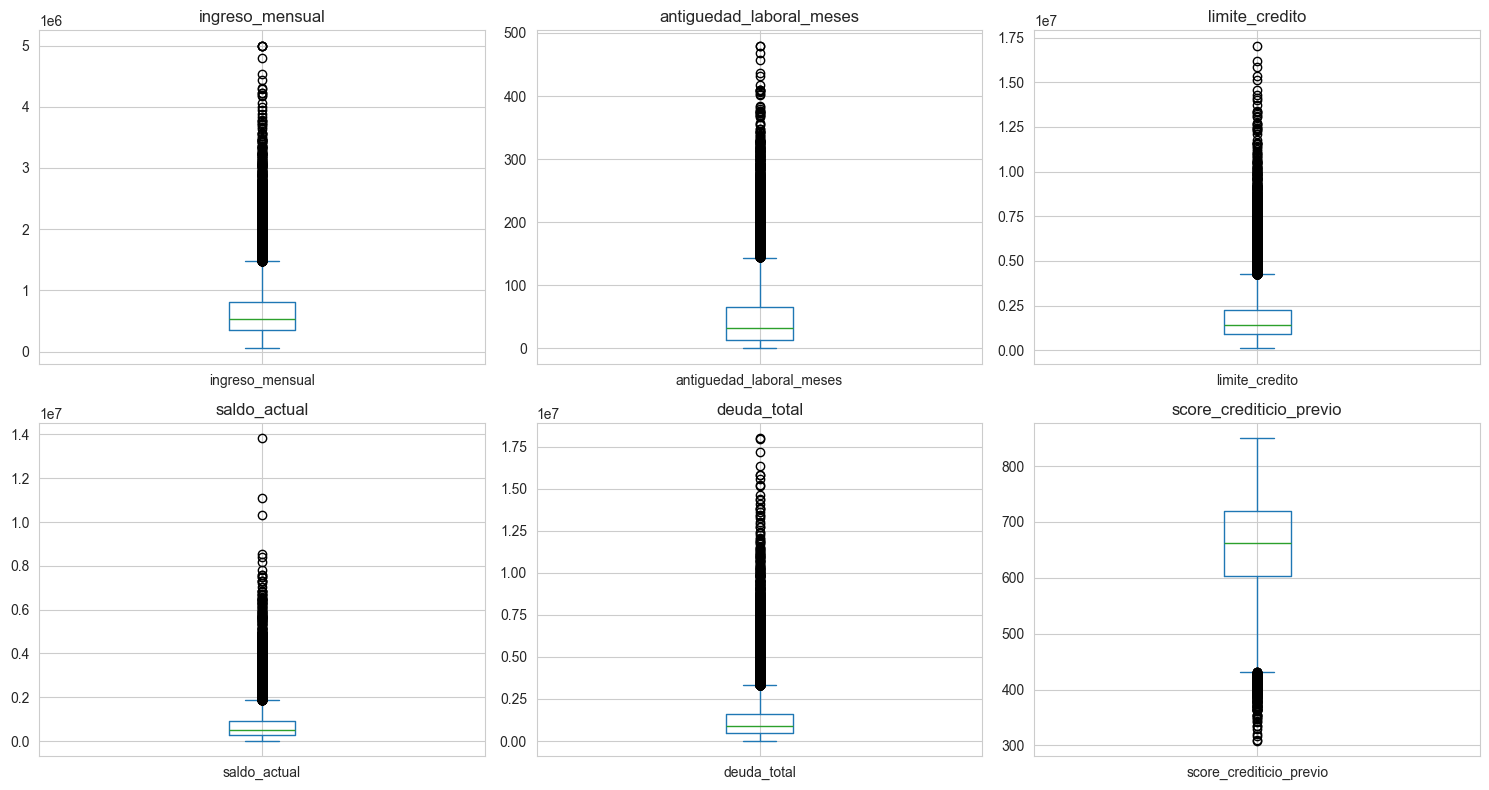

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, c in enumerate(['ingreso_mensual', 'antiguedad_laboral_meses', 'limite_credito',
                        'saldo_actual', 'deuda_total', 'score_crediticio_previo']):
    df[c].plot(kind='box', ax=axes[i])
    axes[i].set_title(c)
plt.tight_layout()
plt.show()


**Lectura:** hay valores extremos en `ingreso_mensual` (hasta ~5.000.000, muy por encima del
percentil 75) y en `antiguedad_laboral_meses` (hasta 480 meses = 40 años, plausible pero atípico).
No son necesariamente errores — pueden ser clientes reales de alto ingreso o de larga trayectoria
laboral — pero conviene marcarlos como outliers a revisar antes de modelar, en vez de asumir que
son errores de carga o eliminarlos sin criterio.

Un chequeo adicional de exactitud/coherencia lógica: personas con `situacion_laboral = 'Desempleado'`
igual tienen valores cargados en `antiguedad_laboral_meses` e `ingreso_mensual`. Esto **no es
imposible** (podría ser antigüedad en el empleo anterior, o ingreso por otra vía como una pensión),
pero es una inconsistencia semántica que vale la pena señalar y preguntar al área de negocio.

In [13]:
desempleados = df[df['situacion_laboral'] == 'Desempleado']
print("Desempleados con antiguedad_laboral_meses cargada (no nula):",
      desempleados['antiguedad_laboral_meses'].notna().sum(), "de", len(desempleados))
print("Desempleados con ingreso_mensual cargado (no nulo):",
      desempleados['ingreso_mensual'].notna().sum(), "de", len(desempleados))
desempleados[['antiguedad_laboral_meses', 'ingreso_mensual']].describe()


Desempleados con antiguedad_laboral_meses cargada (no nula): 5261 de 5485
Desempleados con ingreso_mensual cargado (no nulo): 4367 de 5485


,antiguedad_laboral_meses,ingreso_mensual
count,5261.000000,4.367000e+03
mean,48.707660,6.394245e+05
std,48.523732,4.080954e+05
min,0.000000,6.737100e+04
25%,14.000000,3.553440e+05
50%,34.000000,5.339290e+05
75%,68.000000,8.132105e+05
max,480.000000,3.567357e+06


**Decisión:** no eliminamos estos valores automáticamente. Un valor extremo puede ser real y, sin una regla de negocio que indique lo contrario, borrarlo podría quitar información válida.

En `antiguedad_laboral_meses` conviene además contrastar el valor con la edad del cliente para revisar coherencia (por ejemplo, si la persona tiene edad suficiente para la antigüedad laboral informada).


### 3.6 Actualidad (¿los datos reflejan el momento relevante?)

**Lectura:** el dataset no incluye una columna de fecha o timestamp de carga/observación —
no sabemos a qué momento corresponden estos datos. 

Esto es en sí mismo un hallazgo de calidad: sin fecha de referencia no podemos evaluar
si la información está vigente, y tampoco podemos saber si `atrasos_ultimos_12m` se mide desde
la misma fecha de corte para todos los clientes. 

Es un punto a levantar con el área de negocio:
pedir la fecha de extracción/corte del dataset.

## 4. Clasificación de datos faltantes (MCAR / MAR / MNAR)

Para cada columna con valores faltantes, buscamos evidencia de si la ausencia se relaciona
con otras variables observadas (lo que sugeriría **MAR**, faltante al azar condicionado),
si parece puramente aleatoria (**MCAR**), o si la ausencia depende del propio valor no
observado (**MNAR**, lo más difícil de probar solo con los datos disponibles).

### 4.1 `ingreso_mensual` — ¿falta más según `situacion_laboral`?

In [14]:
tabla = df.groupby('situacion_laboral')['ingreso_mensual'].apply(lambda x: x.isna().mean() * 100).round(1)
tabla = tabla.sort_values(ascending=False)
tabla


situacion_laboral
Independiente/Monotributista    35.6
Desempleado                     20.4
Relacion de dependencia          3.1
Jubilado                         2.8
Name: ingreso_mensual, dtype: float64

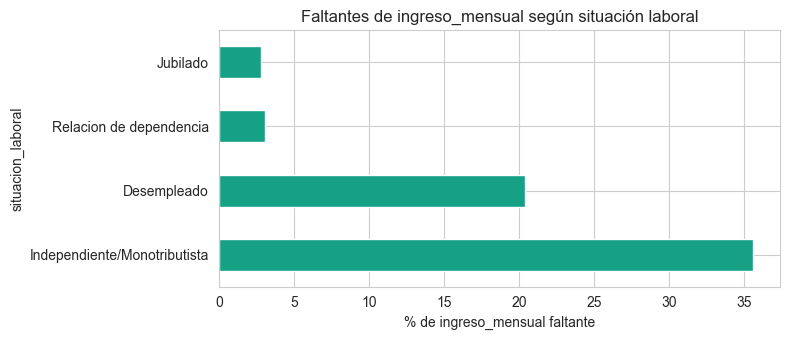

In [15]:
tabla.plot(kind='barh', color='#16a085', figsize=(8, 3.5))
plt.xlabel('% de ingreso_mensual faltante')
plt.title('Faltantes de ingreso_mensual según situación laboral')
plt.tight_layout()
plt.show()


**Clasificación propuesta: MAR (Missing At Random, condicionado a una variable observada).**
El porcentaje de faltantes en `ingreso_mensual` varía claramente según `situacion_laboral`
— es razonable que sea mucho más alto entre desempleados (no hay un ingreso fijo que declarar)
que entre quienes están en relación de dependencia. La ausencia se explica por otra variable
que sí tenemos, no por el valor mismo del ingreso.

### 4.2 `score_crediticio_previo` — ¿falta según antigüedad como cliente?

In [16]:
df['bucket_antiguedad'] = pd.cut(df['antiguedad_cliente_meses'],
                                   bins=[0, 12, 24, 48, 100, 1000],
                                   labels=['0-12m', '12-24m', '24-48m', '48-100m', '100m+'])
tabla2 = df.groupby('bucket_antiguedad', observed=True)['score_crediticio_previo'].apply(
    lambda x: x.isna().mean() * 100).round(1)
tabla2


bucket_antiguedad
0-12m      13.1
12-24m     12.5
24-48m     12.4
48-100m    12.2
100m+      13.4
Name: score_crediticio_previo, dtype: float64

**Clasificación propuesta: MAR.** Es esperable que clientes más nuevos del banco tengan más
probabilidad de no contar todavía con un `score_crediticio_previo` cargado en el sistema (por
ejemplo, si el score se actualiza recién después de cierta antigüedad, o si viene de un buró
externo que tarda en integrarse). Si el patrón de la tabla confirma que los faltantes se
concentran en los clientes de menor antigüedad, la ausencia depende de una variable observada
(`antiguedad_cliente_meses`), no del valor del score en sí.

### 4.3 `atrasos_ultimos_12m` y `num_dependientes` — ¿candidatos a MCAR?

In [17]:
for col in ['atrasos_ultimos_12m', 'num_dependientes']:
    print(f"--- {col} ---")
    print(df.groupby('situacion_laboral')[col].apply(lambda x: x.isna().mean() * 100).round(1))
    print()


--- atrasos_ultimos_12m ---
situacion_laboral
Desempleado                     4.8
Independiente/Monotributista    4.9
Jubilado                        4.6
Relacion de dependencia         4.9
Name: atrasos_ultimos_12m, dtype: float64

--- num_dependientes ---
situacion_laboral
Desempleado                     5.8
Independiente/Monotributista    5.8
Jubilado                        6.0
Relacion de dependencia         5.7
Name: num_dependientes, dtype: float64



**Clasificación propuesta: MCAR (o cercano a MCAR), a confirmar.** Si el porcentaje de
faltantes de estas dos columnas se mantiene relativamente parejo entre grupos (sin un patrón
claro respecto a `situacion_laboral` u otras variables), la hipótesis más razonable es que
sean faltantes por motivos operativos ajenos a los datos de negocio en sí (por ejemplo, campos
que el cliente no completó en un formulario, o un error puntual de integración) — es decir,
**MCAR**. Ninguna clasificación de faltantes puede probarse con certeza absoluta solo mirando
los datos; esto queda como hipótesis a validar con el área que carga la información.

### 4.4 `antiguedad_laboral_meses` — posible MNAR

Un caso más delicado es `antiguedad_laboral_meses`. Si la ausencia estuviera relacionada no solo con una variable observada como `situacion_laboral`, sino también con la propia antigüedad no registrada, podría tratarse de un mecanismo **MNAR**.

Con los datos disponibles no podemos demostrarlo. Por eso lo documentamos como **hipótesis a validar con el área de negocio** y evitamos presentar esta clasificación como una certeza.


In [18]:
df.groupby('situacion_laboral')['antiguedad_laboral_meses'].apply(
    lambda x: x.isna().mean() * 100).round(1)


situacion_laboral
Desempleado                      4.1
Independiente/Monotributista     4.0
Jubilado                        50.1
Relacion de dependencia          4.1
Name: antiguedad_laboral_meses, dtype: float64

## 5. Detección de sesgos potenciales

Buscamos si el dataset representa de forma pareja a los distintos grupos, o si hay
desbalances que puedan traducirse en un modelo sesgado.

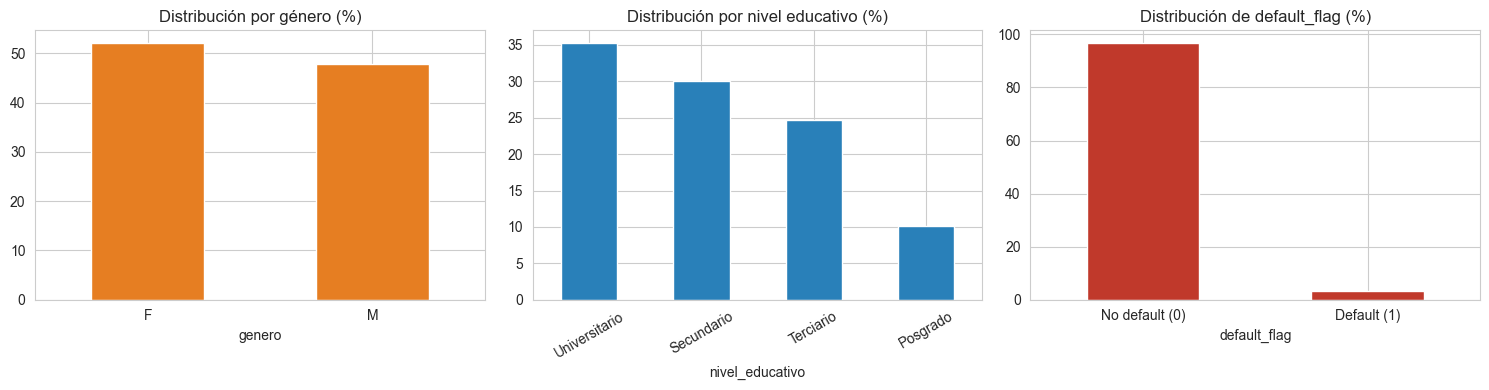

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['genero'].value_counts(normalize=True).mul(100).plot(kind='bar', ax=axes[0], color='#e67e22')
axes[0].set_title('Distribución por género (%)')
axes[0].tick_params(axis='x', rotation=0)

df['nivel_educativo'].value_counts(normalize=True).mul(100).plot(kind='bar', ax=axes[1], color='#2980b9')
axes[1].set_title('Distribución por nivel educativo (%)')
axes[1].tick_params(axis='x', rotation=30)

df['default_flag'].value_counts(normalize=True).mul(100).plot(kind='bar', ax=axes[2], color='#c0392b')
axes[2].set_title('Distribución de default_flag (%)')
axes[2].set_xticklabels(['No default (0)', 'Default (1)'], rotation=0)

plt.tight_layout()
plt.show()


In [20]:
print("Tasa de default por género:")
print((df.groupby('genero')['default_flag'].mean() * 100).round(2))
print()
print("Tasa de default por nivel educativo:")
print((df.groupby('nivel_educativo')['default_flag'].mean() * 100).round(2))
print()
print("Tasa de default por situación laboral:")
print((df.groupby('situacion_laboral')['default_flag'].mean() * 100).round(2))


Tasa de default por género:
genero
F    3.35
M    3.29
Name: default_flag, dtype: float64

Tasa de default por nivel educativo:
nivel_educativo
Posgrado         3.63
Secundario       3.18
Terciario        3.38
Universitario    3.31
Name: default_flag, dtype: float64

Tasa de default por situación laboral:
situacion_laboral
Desempleado                     4.21
Independiente/Monotributista    3.40
Jubilado                        3.42
Relacion de dependencia         3.11
Name: default_flag, dtype: float64


**Hallazgos de sesgo a documentar:**

1. **Desbalance de clases fuerte en la variable objetivo**: solo ~3.3% de los clientes tiene
   `default_flag = 1`. Esto no es un "error" del dataset, pero es un sesgo estructural que va a
   condicionar cualquier modelo posterior (hay que usar métricas que no sean solo *accuracy*,
   y probablemente técnicas de balanceo).
2. Si alguna categoría de `situacion_laboral`, `nivel_educativo` o `genero` está sub-representada
   en volumen de clientes, un modelo entrenado sobre este dataset va a tener menos evidencia para
   esos grupos y podría discriminar peor (o de forma menos confiable) sobre ellos — algo
   especialmente sensible en un caso de riesgo crediticio, donde un modelo sesgado puede traducirse
   en decisiones de negocio injustas sobre personas reales.
3. Al ser `genero` y `estado_civil` variables potencialmente protegidas, cualquier modelo que las
   use (directa o indirectamente, vía variables correlacionadas) debería auditarse por *fairness*
   antes de ponerse en producción — esto queda para la Fase 2/3 del proyecto, pero se marca acá
   como hallazgo temprano.

## 6. Preguntas de negocio que guían el análisis

El objetivo no es solamente describir la cartera, sino usar los datos para responder preguntas que puedan ayudar al área de Riesgo a tomar decisiones. Para este trabajo planteamos tres preguntas:

1. **¿Qué características presentan los clientes con mayor tasa de incumplimiento?**  
   Buscamos comparar la morosidad según variables como situación laboral, nivel educativo, antigüedad como cliente, atrasos previos y nivel de endeudamiento.

2. **¿Cómo se relacionan el uso del crédito, la deuda y los atrasos previos con el riesgo de default?**  
   Esta pregunta permite identificar señales de comportamiento financiero asociadas al incumplimiento y orientar futuros criterios de seguimiento de cartera.

3. **¿Existen diferencias relevantes en la tasa de default entre distintos segmentos de clientes?**  
   La comparación por segmentos sirve para detectar concentraciones de riesgo y, al mismo tiempo, revisar posibles sesgos antes de utilizar estas variables en decisiones automatizadas.

Estas preguntas también sirven como hilo conductor del dashboard: los indicadores y filtros deberían ayudar a responderlas, en lugar de mostrar métricas aisladas.


## 7. EDA: distribuciones de variables clave y primeras correlaciones

Con la calidad de datos ya auditada y las preguntas de negocio definidas, exploramos las variables numéricas más relevantes para el problema de riesgo crediticio y una primera mirada a cómo se relacionan entre sí.


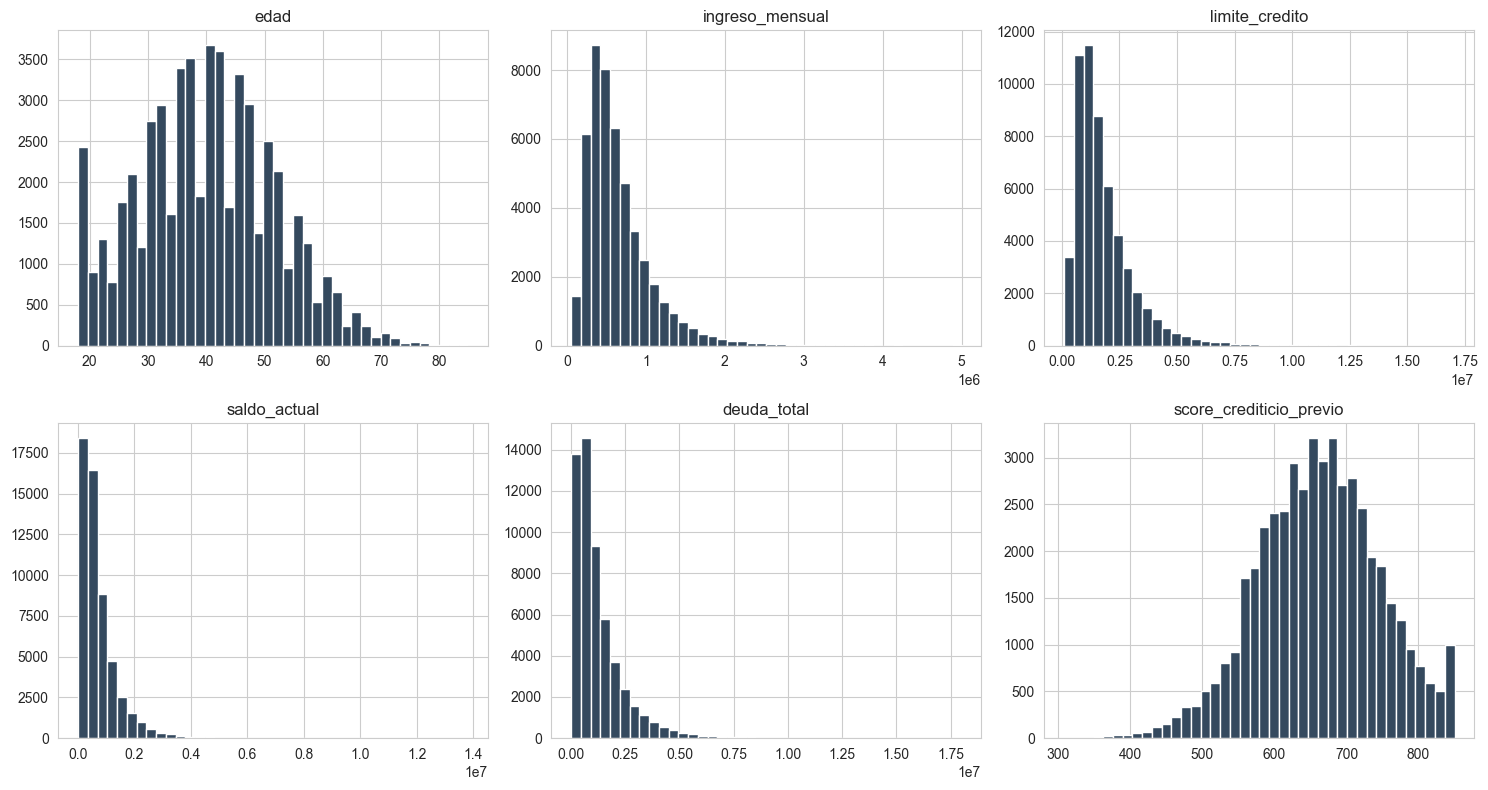

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols = ['edad', 'ingreso_mensual', 'limite_credito', 'saldo_actual', 'deuda_total', 'score_crediticio_previo']
for ax, c in zip(axes.flatten(), cols):
    df[c].dropna().hist(bins=40, ax=ax, color='#34495e')
    ax.set_title(c)
plt.tight_layout()
plt.show()


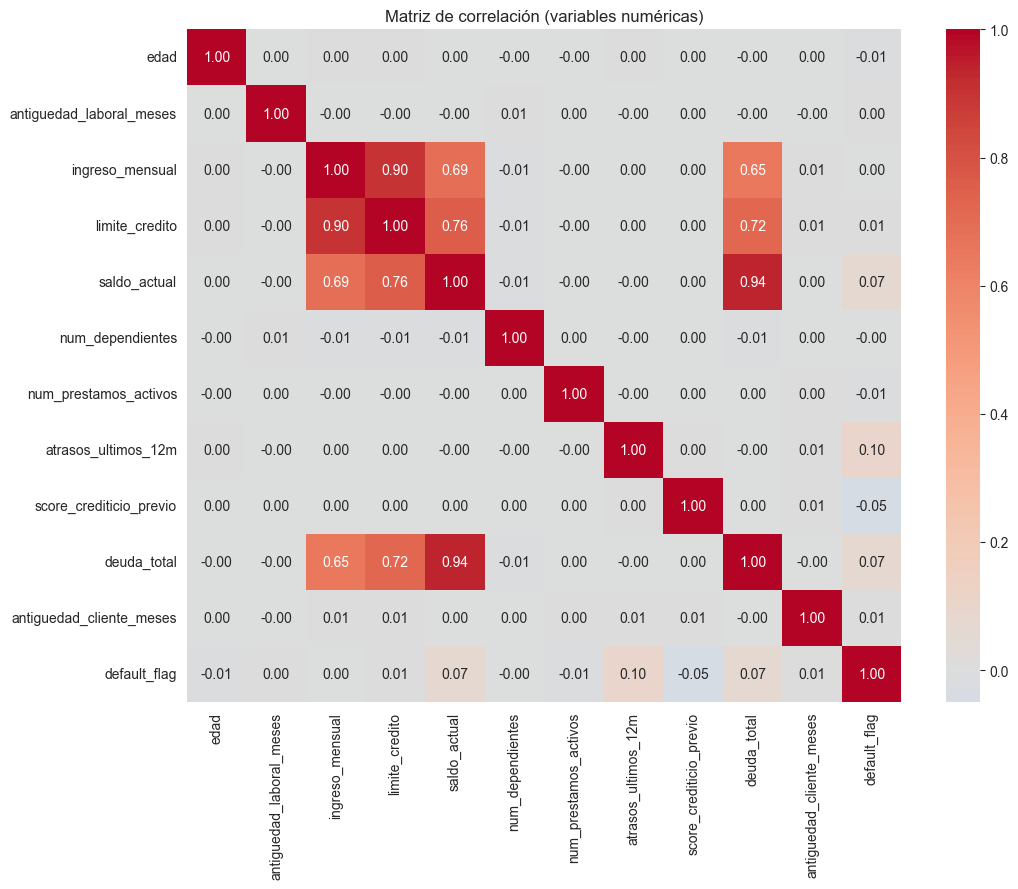

In [22]:
num_cols_corr = ['edad', 'antiguedad_laboral_meses', 'ingreso_mensual', 'limite_credito',
                  'saldo_actual', 'num_dependientes', 'num_prestamos_activos',
                  'atrasos_ultimos_12m', 'score_crediticio_previo', 'deuda_total',
                  'antiguedad_cliente_meses', 'default_flag']

corr = df[num_cols_corr].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
plt.title('Matriz de correlación (variables numéricas)')
plt.tight_layout()
plt.show()


### Paso previo a cualquier modelado

Antes de utilizar `ratio_uso_credito` en un modelo o en indicadores derivados, debemos trabajar con la versión normalizada definida en el ETL.


In [23]:
corr['default_flag'].sort_values(ascending=False)


default_flag                1.000000
atrasos_ultimos_12m         0.100767
deuda_total                 0.072278
saldo_actual                0.071195
limite_credito              0.009224
antiguedad_cliente_meses    0.005532
antiguedad_laboral_meses    0.003523
ingreso_mensual             0.001742
num_dependientes           -0.000362
edad                       -0.005306
num_prestamos_activos      -0.007251
score_crediticio_previo    -0.049991
Name: default_flag, dtype: float64

**Lectura preliminar:** la correlación lineal con `default_flag` se utiliza solo como una primera exploración y no implica causalidad. En este dataset, las asociaciones numéricas más relevantes deben interpretarse a partir de la tabla calculada arriba, en conjunto con el conocimiento de negocio.

Además, `ratio_uso_credito` presenta la inconsistencia de escala detectada en la Sección 3.3, por lo que para análisis posteriores corresponde utilizar `ratio_uso_credito_normalizado`, generado en el ETL.


## 8. Síntesis

**Resumen de calidad de datos:**

| Dimensión | Estado | Hallazgo principal |
|---|---|---|
| Completitud | Parcial | 5 columnas con faltantes (hasta ~13%), ninguna en el target |
| Unicidad | OK | Sin duplicados, `id_cliente` único |
| Consistencia | Problema encontrado | `ratio_uso_credito` mezcla dos escalas distintas (proporción y por mil) |
| Validez | OK | Rangos y categorías dentro de dominio esperado |
| Exactitud | A revisar | Outliers en ingreso y antigüedad laboral; casos semánticos a validar |
| Actualidad | Sin poder evaluar | No hay fecha de corte/extracción en el dataset |

La auditoría permite definir qué transformaciones son necesarias antes de continuar. Las decisiones de limpieza y normalización se implementan en `ETL_riesgo_crediticio.ipynb`.
